# 04 — Logistic Regression
**Loan Approval Prediction**

Goals:
- Train a Logistic Regression model as a strong interpretable baseline
- Compare performance with and without SMOTE
- Tune the regularisation parameter C via cross-validation
- Evaluate using precision, recall, F1-score, and ROC-AUC
- Inspect feature coefficients for interpretability

**Prerequisite**: Notebooks 02 and 03 must have been run.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, f1_score

from src.config import DATA_DIR, MODELS_DIR, LR_MODEL_FILE, RANDOM_STATE
from src.models import (
    get_logistic_regression,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_precision_recall,
)

warnings.filterwarnings('ignore')
print("Imports OK — Data dir:", DATA_DIR)

Imports OK — Data dir: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/data


## 1. Load Data

In [2]:
import numpy as np

X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
X_smote = np.load(os.path.join(DATA_DIR, 'X_smote.npy'))
y_smote = np.load(os.path.join(DATA_DIR, 'y_smote.npy'))

import pickle
with open(os.path.join(DATA_DIR, 'feature_names.pkl'), 'rb') as f:
    feature_names = pickle.load(f)

print(f"Train  : {X_train.shape},  SMOTE : {X_smote.shape},  Test : {X_test.shape}")
print(f"Feature names ({len(feature_names)}): {feature_names}")

Train  : (3415, 11),  SMOTE : (4250, 11),  Test : (854, 11)
Feature names (11): ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


## 2. Baseline — No Resampling

In [3]:
lr_base = get_logistic_regression(C=1.0)
lr_base.fit(X_train, y_train)
metrics_base = evaluate_model(lr_base, X_test, y_test, "LR — Baseline (no resampling)")


═══════════════════════════════════════════════════════
  LR — Baseline (no resampling)  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.90      0.87      0.88       323
Approved (1)       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854

  ROC-AUC : 0.9726


## 3. With SMOTE Oversampling

In [4]:
lr_smote = get_logistic_regression(C=1.0)
lr_smote.fit(X_smote, y_smote)
metrics_smote = evaluate_model(lr_smote, X_test, y_test, "LR — Trained on SMOTE data")


═══════════════════════════════════════════════════════
  LR — Trained on SMOTE data  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.88      0.92      0.90       323
Approved (1)       0.95      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854

  ROC-AUC : 0.9732


## 4. Class-Weight Balancing (built-in alternative)

In [5]:
lr_weighted = get_logistic_regression(C=1.0, class_weight='balanced')
lr_weighted.fit(X_train, y_train)
metrics_weighted = evaluate_model(lr_weighted, X_test, y_test, "LR — class_weight='balanced'")


═══════════════════════════════════════════════════════
  LR — class_weight='balanced'  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.88      0.93      0.90       323
Approved (1)       0.96      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.93      0.92      0.92       854

  ROC-AUC : 0.9734


## 5. Hyperparameter Tuning — Regularisation C

  C=0.001     CV Macro-F1 = 0.9299
  C=0.010     CV Macro-F1 = 0.9296
  C=0.100     CV Macro-F1 = 0.9254
  C=0.500     CV Macro-F1 = 0.9256
  C=1.000     CV Macro-F1 = 0.9249
  C=5.000     CV Macro-F1 = 0.9247
  C=10.000    CV Macro-F1 = 0.9252
  C=50.000    CV Macro-F1 = 0.9254
  C=100.000   CV Macro-F1 = 0.9254

Best C = 0.001  (CV Macro-F1 = 0.9299)


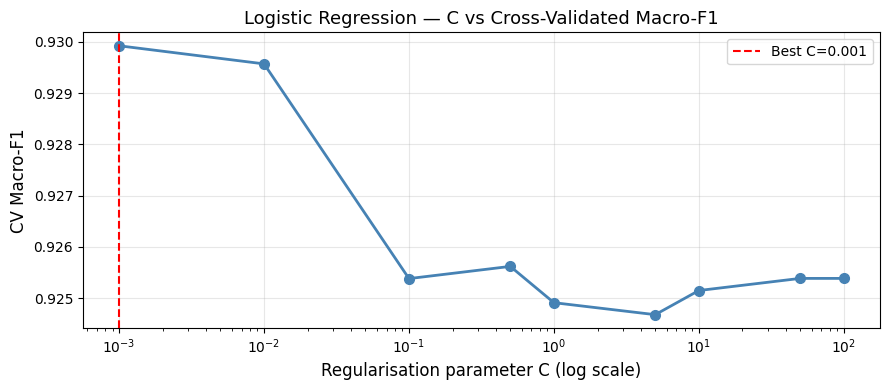

In [6]:
C_values  = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
cv_scores = []

for C in C_values:
    model = get_logistic_regression(C=C)
    score = cross_val_score(
        model, X_smote, y_smote, cv=5, scoring='f1_macro', n_jobs=-1
    ).mean()
    cv_scores.append(score)
    print(f"  C={C:<8.3f}  CV Macro-F1 = {score:.4f}")

best_C = C_values[int(np.argmax(cv_scores))]
print(f"\nBest C = {best_C}  (CV Macro-F1 = {max(cv_scores):.4f})")

# Plot C vs CV-F1 curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_values, cv_scores, marker='o', color='steelblue', lw=2, markersize=7)
ax.axvline(best_C, color='red', linestyle='--', label=f'Best C={best_C}')
ax.set_xlabel('Regularisation parameter C (log scale)', fontsize=12)
ax.set_ylabel('CV Macro-F1', fontsize=12)
ax.set_title('Logistic Regression — C vs Cross-Validated Macro-F1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Best Model Evaluation

In [7]:
lr_best = get_logistic_regression(C=best_C)
lr_best.fit(X_smote, y_smote)
metrics_best = evaluate_model(lr_best, X_test, y_test, f"LR — Best C={best_C} (SMOTE)")


═══════════════════════════════════════════════════════
  LR — Best C=0.001 (SMOTE)  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.86      0.98      0.92       323
Approved (1)       0.98      0.91      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.94      0.93       854
weighted avg       0.94      0.93      0.93       854

  ROC-AUC : 0.9738


## 7. Confusion Matrix

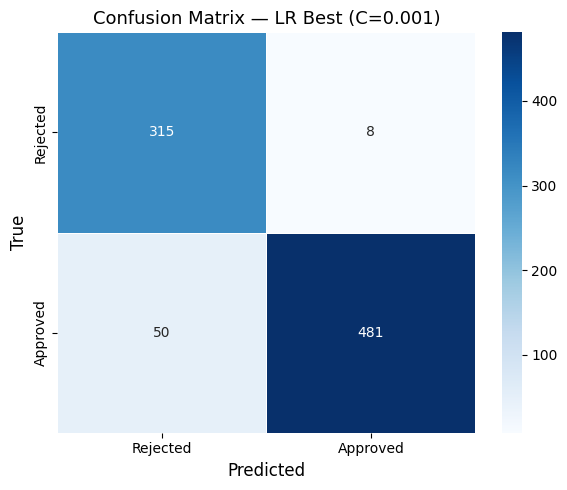

array([[315,   8],
       [ 50, 481]])

In [8]:
from src.models import plot_confusion_matrix

y_pred_best = lr_best.predict(X_test)
plot_confusion_matrix(
    y_test,
    y_pred_best,
    title=f"Confusion Matrix — LR Best (C={best_C})"
)

## 8. ROC Curve & Precision-Recall

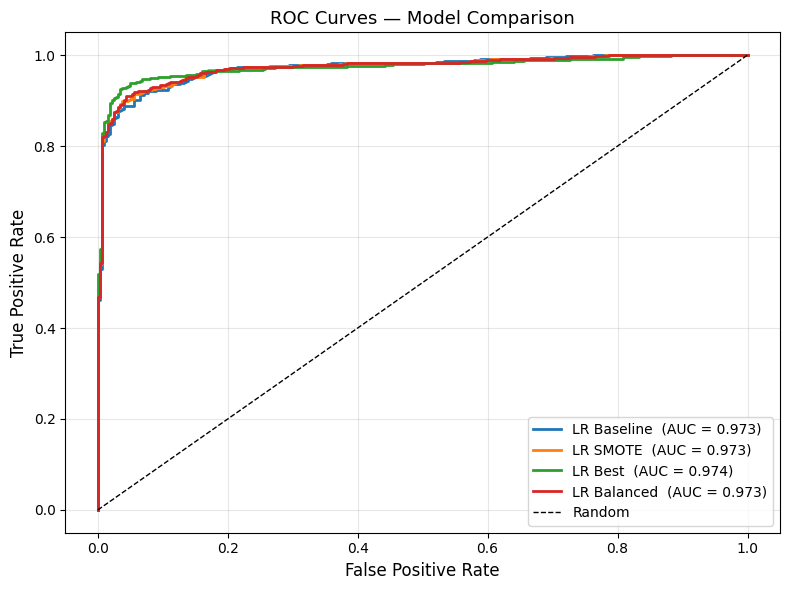

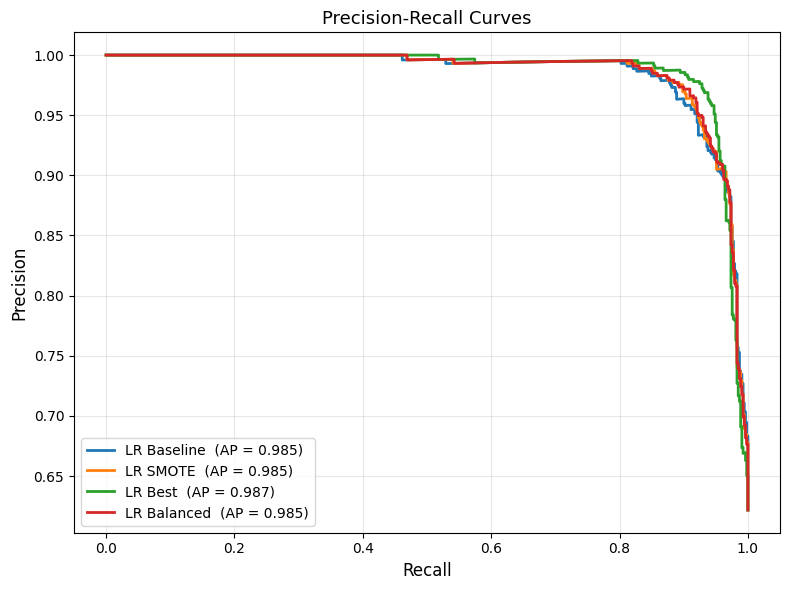

In [9]:
models_dict = {
    'LR Baseline': lr_base,
    'LR SMOTE'   : lr_smote,
    'LR Best'    : lr_best,
    'LR Balanced': lr_weighted,
}

plot_roc_curves(models_dict, X_test, y_test)
plot_precision_recall(models_dict, X_test, y_test)

## 9. Feature Coefficients

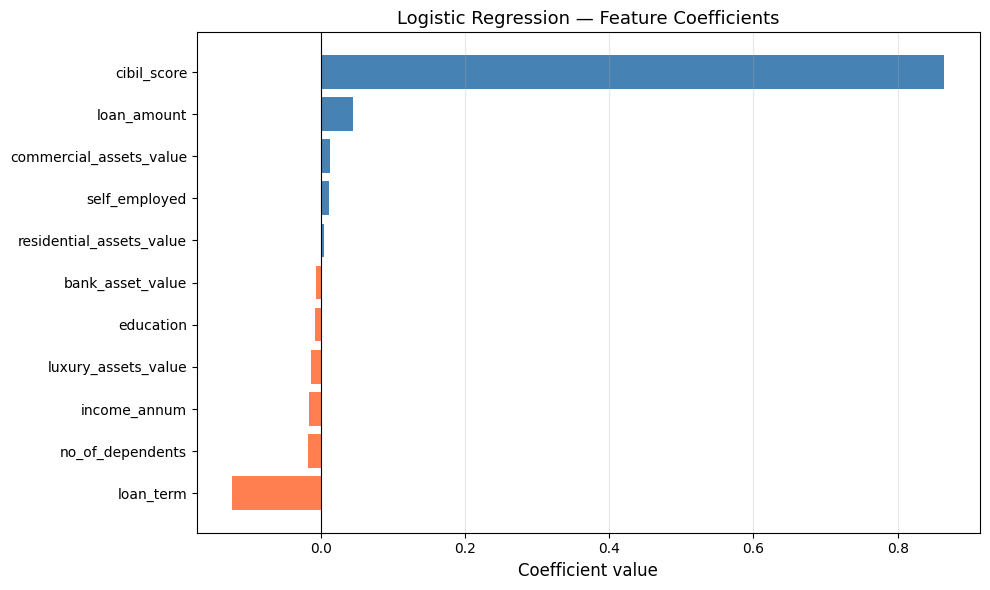


Top positive coefficients (increase approval probability):
                 feature  coefficient
residential_assets_value     0.004699
           self_employed     0.011657
 commercial_assets_value     0.012593
             loan_amount     0.044881
             cibil_score     0.864791

Top negative coefficients (decrease approval probability):
            feature  coefficient
          loan_term    -0.122545
   no_of_dependents    -0.017762
       income_annum    -0.016017
luxury_assets_value    -0.013894
          education    -0.007485


In [10]:
coefs = lr_best.coef_[0]
coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    .sort_values('coefficient')
)

plt.figure(figsize=(10, 6))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient value', fontsize=12)
plt.title('Logistic Regression — Feature Coefficients', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop positive coefficients (increase approval probability):")
print(coef_df.tail(5).to_string(index=False))
print("\nTop negative coefficients (decrease approval probability):")
print(coef_df.head(5).to_string(index=False))

## 10. Save Best Model

In [11]:
import pickle

os.makedirs(MODELS_DIR, exist_ok=True)

with open(LR_MODEL_FILE, 'wb') as f:
    pickle.dump(lr_best, f)

print(f"Model saved → {LR_MODEL_FILE}")

# Summary of all variants
summary = pd.DataFrame([metrics_base, metrics_smote, metrics_weighted, metrics_best])
summary = summary.set_index('model')
print("\nSummary — Logistic Regression variants:")
display(summary[['accuracy', 'f1_macro', 'f1_approved', 'f1_rejected', 'roc_auc']].round(4))

Model saved → /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/models/logistic_regression.pkl

Summary — Logistic Regression variants:


,accuracy,f1_macro,f1_approved,f1_rejected,roc_auc
model,,,,,
LR — Baseline (no resampling),0.9133,0.9072,0.9311,0.8833,0.9726
LR — Trained on SMOTE data,0.9227,0.9186,0.9369,0.9003,0.9732
LR — class_weight='balanced',0.9239,0.9200,0.9377,0.9023,0.9734
LR — Best C=0.001 (SMOTE),0.9321,0.9294,0.9431,0.9157,0.9738
